# Từ quyết định phát triển đến bài nộp

[Bài 05](05_backbone_and_selection.ipynb) sàng lọc các cách nhìn ảnh và backbone, rồi chọn mô hình đơn sau ba seed. [Bài 06](06_errors_and_blend.ipynb) kiểm tra mô hình đó có nên kết hợp với native hay không. Bây giờ ta giữ quyết định ấy để trả lời câu hỏi: các ý tưởng vừa thử biểu hiện ra sao trên private, và xuất bài bằng mô hình nào?

Notebook nhận checkpoint và quyết định của lượt chạy hiện tại. Mặc định dùng ensemble ba fold; train lại trên toàn bộ 1.000 cặp là một chiến lược nộp riêng, cần chọn trước khi xem private.

Nếu muốn đối chiếu cả phụ lục, chạy A-D trước bước khóa dưới đây và đặt `KMD_INCLUDE_EXTENSIONS=1`. Dùng cùng `KMD_RUN_ID` cho cả chuỗi. Danh sách mặc định đã bao gồm các cấu hình sàng lọc ở bài 05, kể cả cấu hình không vào shortlist.

In [1]:
from pathlib import Path
import os
import sys

def find_task_root():
    explicit = os.environ.get('KMD_PROJECT_ROOT')
    if explicit:
        root = Path(explicit).expanduser().resolve()
        if (root / 'src/kmd').is_dir():
            return root
        raise FileNotFoundError('KMD_PROJECT_ROOT phải trỏ đến thư mục KeMaoDanh chứa src/kmd.')
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / 'src/kmd').is_dir() and (cand / 'configs').is_dir():
            return cand.resolve()
        if (cand / 'KeMaoDanh/src/kmd').is_dir() and (cand / 'KeMaoDanh/configs').is_dir():
            return (cand / 'KeMaoDanh').resolve()
    raise FileNotFoundError("Không tìm thấy thư mục gốc KeMaoDanh chứa 'src/kmd' và 'configs'.")

TASK_ROOT = find_task_root()
if str(TASK_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(TASK_ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kmd.core import read_csv, read_json, export_submission, write_json
from kmd.pipeline import prepare_development, start_session, load_pairs, complete_method_cv, aligned_predictions
from kmd.teaching import resolve_data_roots
from kmd.finalization import (MAIN_METHODS, EXTENSION_METHODS, freeze_review,
    predict_frozen_comparison, score_private, infer_method, refit_config, refit_all, infer_refit)

data_root, test_root = resolve_data_roots(TASK_ROOT)
RUN_ID = os.environ.get('KMD_RUN_ID', 'reasoning_pilot')
if os.environ.get('KMD_SMOKE', '0') == '1' or RUN_ID.endswith('_smoke'):
    raise ValueError('Bước chốt và nộp bài yêu cầu kết quả full, không dùng smoke.')
dev_frame = prepare_development(data_root)
session_dir = start_session(dev_frame, data_root, run_id=RUN_ID)
INCLUDE_EXTENSIONS = os.environ.get('KMD_INCLUDE_EXTENSIONS', '0') == '1'
STRATEGY = os.environ.get('KMD_SUBMISSION_STRATEGY', 'fold_ensemble')
if STRATEGY not in {'fold_ensemble', 'refit_all'}:
    raise ValueError('Chọn fold_ensemble hoặc refit_all trước khi xem private.')
print('Phiên:', session_dir, '| Chiến lược nộp:', STRATEGY)

Phiên: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920 | Chiến lược nộp: fold_ensemble


## 1. Giữ nguyên quyết định trước khi xem private

Ta không mặc định B2 sẽ thắng. Bài 05 lấy hai challenger có F1 cao nhất ở seed đầu để xác nhận cùng ba mốc DenseNet-224 cap 24, DenseNet-224 cap 48 và native. Cấu hình có F1 trung bình tốt nhất trong năm mô hình được xác nhận là mô hình đơn được chọn. Bài 06 chỉ thay nó bằng blend 50/50 với native nếu mức tăng F1 trung bình đạt ít nhất 0,50 điểm phần trăm. Nếu native đứng đầu, không có phép blend native với chính nó.

Cell dưới đọc lại quyết định và xác minh các artifact phát triển. Các nhánh frozen/resampled mới chạy fold0 được hoàn thành OOF để đối chiếu private bằng cùng giao thức. Bước này không mở nhãn private.

`review_freeze.json` lưu phương pháp, thành phần blend nếu có, chiến lược nộp, danh sách đối chiếu và mã kiểm tra các tệp. Đổi lựa chọn trong cùng phiên sau khi khóa sẽ bị từ chối. Tạo một phiên mới không làm dữ liệu private đã xem trở thành một phép kiểm tra độc lập mới.

In [2]:
from kmd.decision_flow import run_selected_blend_suite

for name in ('frozen', 'resampled'):
    complete_method_cv(name, dev_frame, data_root, session_dir, smoke=False)

# Không train lại shortlist ở đây: hàm xác minh lựa chọn từ bài 05 và tính blend từ OOF.
blend_table, decision = run_selected_blend_suite(dev_frame, data_root, session_dir, smoke=False)
if decision is None:
    raise ValueError('Chưa có quyết định full hợp lệ từ bài 05-06.')
selection = dict(decision)
selection['submission_strategy'] = STRATEGY
methods = list(dict.fromkeys(selection['comparison_methods']
                           + (EXTENSION_METHODS if INCLUDE_EXTENSIONS else [])))
frozen = freeze_review(session_dir, methods, selection)
print('Mô hình đơn được chọn:', selection['best_single'])
print('Phương pháp nộp:', selection['method'])
print('Trạng thái thử blend:', selection['blend_status'])
if selection['components']:
    print('Thành phần và trọng số:', list(zip(selection['components'], selection['weights'])))
print('Danh sách đối chiếu private:', methods)

Mô hình đơn được chọn: b2
Phương pháp nộp: b2
Trạng thái thử blend: tested
Thành phần và trọng số: [('b2', 0.5), ('native', 0.5)]
Danh sách đối chiếu private: ['lr_full32', 'frozen', 'center60', 'center60_cap48', 'dense288', 'center72', 'b0_224', 'b2_224', 'b2', 'native', 'resampled', 'blend_selected_native', 'lr_filesize_only', 'lr_color_only', 'lr_texture_only', 'lr_center_border_only', 'lr_drop_filesize', 'lr_drop_color', 'lr_drop_texture', 'lr_drop_center_border', 'frozen_lr', 'partial_native', 'partial_resampled', 'top2', 'resnet18_rgb', 'resnet18_gaussian', 'resnet18_npr', 'loss_image', 'loss_pair', 'loss_mixed', 'repair', 'data_25', 'data_50', 'data_100', 'b2_resize']


## 2. Dự đoán trước, chấm điểm sau

`PRIVATE_ROOT` chỉ cần manifest cặp và ảnh. Cell sau chạy mọi phương pháp đã khóa bằng **ensemble ba fold**, lưu xác suất và mã kiểm tra trước khi đọc nhãn. Điều này giữ cùng giao thức suy diễn giữa các ý tưởng.

Nếu chưa có nhãn private đáng tin cậy, bạn vẫn chạy được pipeline và xuất bài. Khi có nhãn, đặt `PRIVATE_LABELS` đến CSV chứa `pair_id,fake_position`; `PRIVATE_LABEL_SOURCE` ghi nhãn đến từ ban tổ chức hay từ một bản dựng lại. Tên `pairs_results.csv` tự nó không chứng minh nguồn nhãn.

In [3]:
# PRIVATE_ROOT chứa pairs.csv không nhãn và ảnh; có thể khác TEST_ROOT dùng nộp.
private_raw = os.environ.get('PRIVATE_ROOT', '').strip()
private_dir = session_dir / 'private_fold_ensemble'
private_ready = False
if private_raw:
    private_root = Path(private_raw).expanduser().resolve()
    prediction_manifest = predict_frozen_comparison(session_dir, private_root, private_dir)
    private_ready = True
    print('Đã lưu toàn bộ dự đoán theo danh sách khóa:', private_dir)
else:
    print('Chưa cấu hình PRIVATE_ROOT: bỏ qua đối chiếu private, vẫn có thể xuất submission.')

Đã lưu toàn bộ dự đoán theo danh sách khóa: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920/private_fold_ensemble


               method  development_f1  private_f1  private_errors  private_n                       protocol
            lr_full32        0.788742    0.839936              16        100 3-fold ensemble, seed 20260917
               frozen        0.817499    0.849985              15        100 3-fold ensemble, seed 20260917
             center60        0.966246    0.939976               6        100 3-fold ensemble, seed 20260917
       center60_cap48        0.968748    0.960000               4        100 3-fold ensemble, seed 20260917
             dense288        0.973750    0.959984               4        100 3-fold ensemble, seed 20260917
             center72        0.954995    0.949995               5        100 3-fold ensemble, seed 20260917
               b0_224        0.961249    0.940000               6        100 3-fold ensemble, seed 20260917
               b2_224        0.965000    0.929993               7        100 3-fold ensemble, seed 20260917
                   b2       

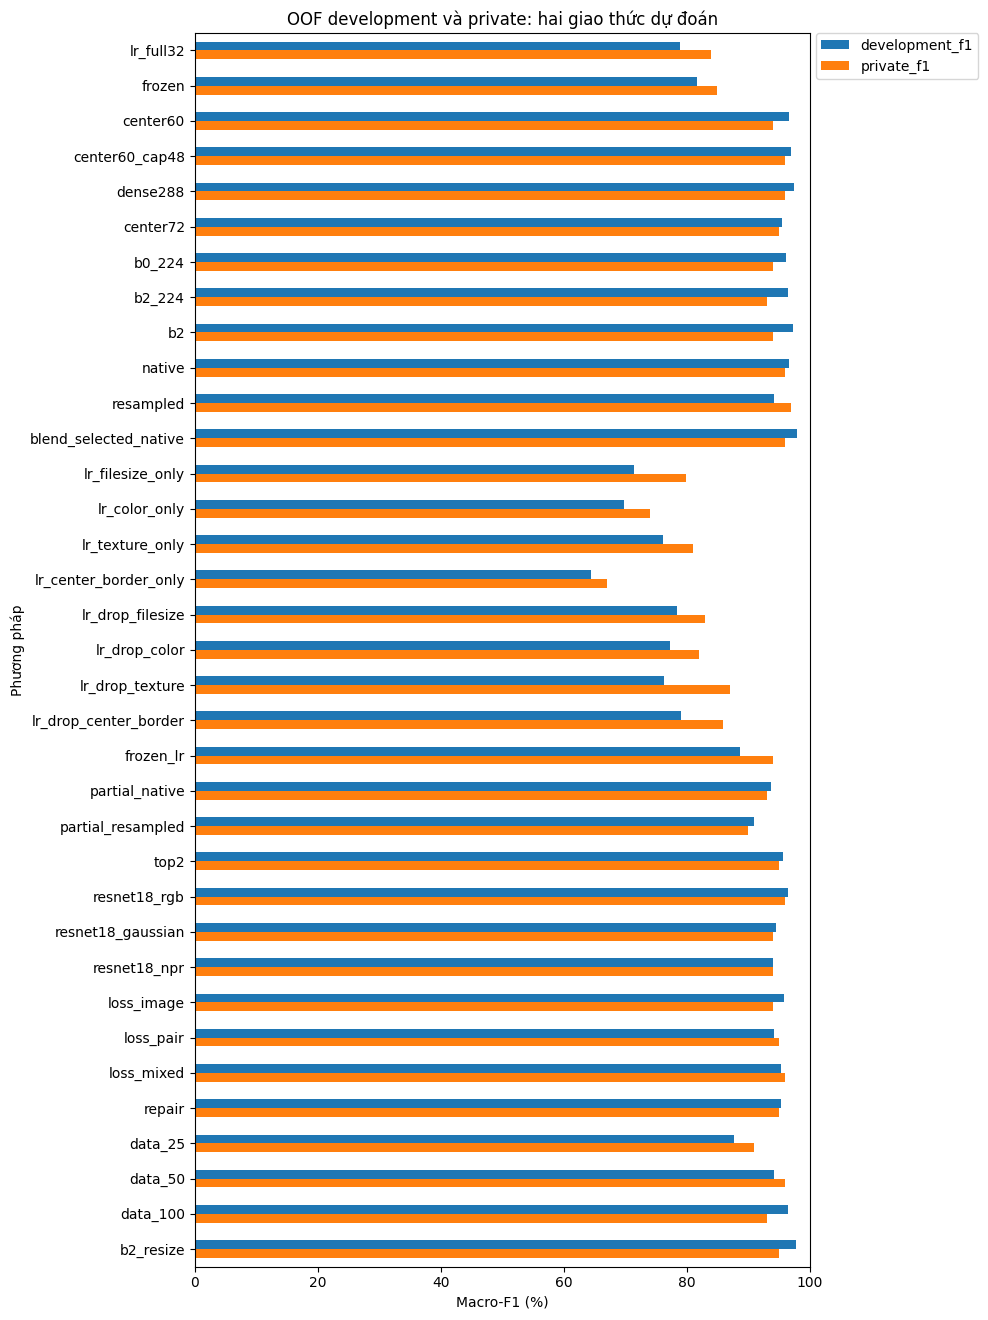

In [4]:
# Đây là bước duy nhất đọc nhãn private. Không dùng bảng này để chọn lại mô hình.
labels_raw = os.environ.get('PRIVATE_LABELS', '').strip()
label_source = os.environ.get('PRIVATE_LABEL_SOURCE', '').strip()
if private_ready and labels_raw and label_source:
    private_table = score_private(session_dir, private_dir, Path(labels_raw), label_source)
    print(private_table.to_string(index=False))
    ax = (private_table.set_index('method')[['development_f1', 'private_f1']] * 100).plot.barh(
        figsize=(10, max(5, len(methods) * .38)), xlim=(0, 100))
    ax.set(xlabel='Macro-F1 (%)', ylabel='Phương pháp', title='OOF development và private: hai giao thức dự đoán')
    ax.invert_yaxis()
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
    plt.tight_layout()
    plt.savefig(private_dir / 'development_private_comparison.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('Chưa chấm private. Cần đủ dự đoán, PRIVATE_LABELS và mô tả PRIVATE_LABEL_SOURCE.')

### Đọc bảng private mà không đổi câu hỏi

Đọc chênh lệch giữa hai phương pháp trên cùng tập: chẳng hạn native so với resampled, hoặc blend so với mô hình đơn được chọn. Ý tưởng có lợi trên development nhưng không có lợi trên private là một kết quả cần ghi nhận. Nếu lợi thế giữ được ở cả hai, ta có thêm bằng chứng trong các tập đang xét; nguyên nhân vẫn cần đối chứng riêng.

Cột development là OOF: mỗi cặp do một mô hình chưa train trên nó dự đoán. Cột private dùng trung bình ba mô hình fold, trên các cặp khác. Vì cả dữ liệu và cách gộp mô hình đều đổi, không gọi hiệu hai cột là phép đo thuần túy khoảng cách tổng quát hóa. Biểu đồ được lưu cạnh bảng CSV để dùng trong bài trình bày.

Nếu nhãn private là bản tái dựng hoặc đã từng được dùng để chọn phương án, ghi đúng trạng thái đó khi trình bày kết quả; bảng này không tạo ra một điểm thi chính thức mới.

## 3. Giữ ensemble hay train lại với toàn bộ dữ liệu?

**Ensemble ba fold (mặc định):** mỗi mạng học khoảng hai phần ba của 800 cặp development. Khi dự đoán test, lấy trung bình xác suất của ba mạng. Không train thêm, nhưng cần suy diễn ba lần cho mỗi nhánh.

**Refit 1.000 cặp:** bắt đầu lại từ pretrained, dùng tất cả cặp có nhãn sau khi đã chọn cấu hình. Mô hình được thấy nhiều dữ liệu hơn nhưng bỏ hiệu ứng trung bình ba mạng, nên chưa biết nó sẽ tốt hơn. Không chọn epoch bằng private: với cấu hình dừng sớm, lấy trung vị best epoch của ba fold ở seed đầu; với native, giữ ngân sách kết thúc 19 epoch. LR khớp lại scaler và bộ phân loại trên 1.000 cặp. Nếu chọn blend, refit riêng hai nhánh đã ghi trong quyết định. Không tự đổi thành B2/native.

Hai trăm cặp từng để riêng nay tham gia train, không còn là holdout của mô hình refit. Thư mục `refit_all` và `submission/refit_all` tách khỏi checkpoint và kết quả ensemble. Nếu cuộc thi cho phép dùng toàn bộ train được phát hành, đây là cách triển khai lựa chọn ấy; không cần nhãn test.

In [5]:
if test_root is None:
    print('Chưa có TEST_ROOT: dừng ở kết quả development; cấu hình test rồi chạy lại cell này để xuất bài.')
else:
    test_frame = load_pairs(test_root, labeled=False)
    method = selection['method']
    if STRATEGY == 'refit_all':
        if method != 'lr_full32':
            for branch in (selection['components'] if method == 'blend_selected_native' else (method,)):
                cfg, fold_epochs = refit_config(branch, session_dir)
                print(branch, '| best epochs từng fold:', fold_epochs, '| ngân sách refit:', cfg.epochs)
        refit_all(method, data_root, session_dir)
        prediction = infer_refit(method, test_frame, test_root, session_dir)
    else:
        prediction = infer_method(method, test_frame, test_root, session_dir)
    prediction = aligned_predictions(prediction, test_frame)
    out_dir = session_dir / 'submission' / STRATEGY
    out_dir.mkdir(parents=True, exist_ok=True)
    prediction[['pair_id', 'p']].to_csv(out_dir / 'probabilities.csv', index=False)
    export_submission(prediction, out_dir / 'submission.csv')
    exported = read_csv(out_dir / 'submission.csv')
    assert exported.pair_id.tolist() == test_frame.pair_id.tolist()
    assert exported.pair_id.is_unique and exported.fake_position.isin([0, 1]).all()
    assert list(exported.columns) == ['pair_id', 'fake_position']
    print('Tệp nộp:', out_dir / 'submission.csv', '| số cặp:', len(exported))
    print(exported.head().to_string(index=False))

Tệp nộp: /home/purin1410-desktop/kmd_full_v5_20260920/repo/KeMaoDanh/artifacts/models/lesson_full_v5_20260920/submission/fold_ensemble/submission.csv | số cặp: 100
pair_id  fake_position
  00001              0
  00002              0
  00003              0
  00004              1
  00005              0


## 4. Trước khi dùng tệp nộp

Đối chiếu số dòng và ID với manifest test, xem cột nhãn chỉ gồm 0/1. CSV đúng định dạng chưa cho biết điểm thi. Ghi kèm phương pháp, chiến lược train, phiên chạy và nguồn nhãn của mọi bảng đánh giá.

Bản thực thi gọn nằm ở [pipeline end-to-end](pipeline_end_to_end.ipynb). Nó gọi cùng các hàm với chuỗi bài học, dành cho lúc đã hiểu và muốn chạy lại toàn bộ.